In [109]:
# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM, anova_lm
from statsmodels.formula.api import ols
import pingouin as pg

In [110]:
# Figure 1h DATA LOADING
data_1h = pd.read_csv('1h.csv')

data_1h = data_1h.rename(columns={'Subject ID': 'Subject_ID'}) # Renaming to avoid spaces in column names


df_1h = data_1h.melt( # put into a df
    id_vars=['Subject_ID', 'Group'], 
    value_vars=['Day 1', 'Day 2', 'Day 3', 'Day 4'],
    var_name='Day',
    value_name='PressRate'
)

df_1h['Day'] = df_1h['Day'].str.replace("Day ", "").astype(int)

print(df_1h.head(28))

   Subject_ID                 Group  Day  PressRate
0    JG28 #17      Control Degraded    1       1.57
1    JG28 #18      Control Degraded    1       2.48
2    JG28 #19      Control Degraded    1       1.65
3    JG28 #20      Control Degraded    1       2.39
4    JG28 #21      Control Degraded    1       1.32
5    JG28 #22      Control Degraded    1       2.94
6    JG28 #23      Control Degraded    1       2.63
7    JG28 #25  Control Non-Degraded    1       1.97
8    JG28 #26  Control Non-Degraded    1       0.95
9    JG28 #27  Control Non-Degraded    1       3.10
10   JG28 #29  Control Non-Degraded    1       1.32
11   JG28 #30  Control Non-Degraded    1       1.85
12   JG28 #31  Control Non-Degraded    1       1.10
13   JG28 #32  Control Non-Degraded    1       1.12
14    JG28 #1       Stress Degraded    1       2.36
15    JG28 #2       Stress Degraded    1       3.26
16    JG28 #3       Stress Degraded    1       1.42
17    JG28 #4       Stress Degraded    1       2.96
18    JG28 #

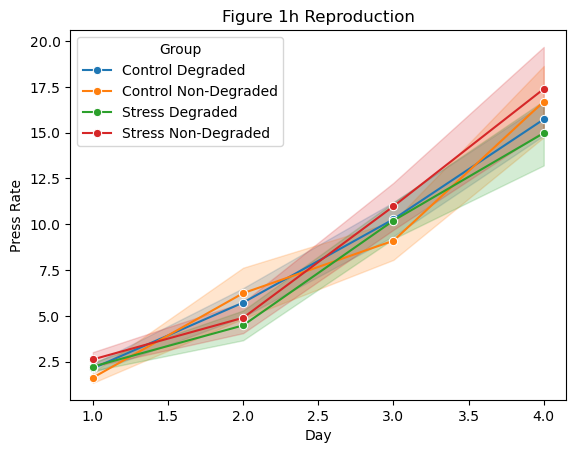

In [111]:
# Plot for Figure 1h

plt.figure()
sns.lineplot(
    data=df_1h,
    x='Day',
    y='PressRate',
    hue='Group',
    errorbar='se',
    marker='o'
)

plt.title('Figure 1h Reproduction')
plt.xlabel('Day')
plt.ylabel('Press Rate')
plt.show()

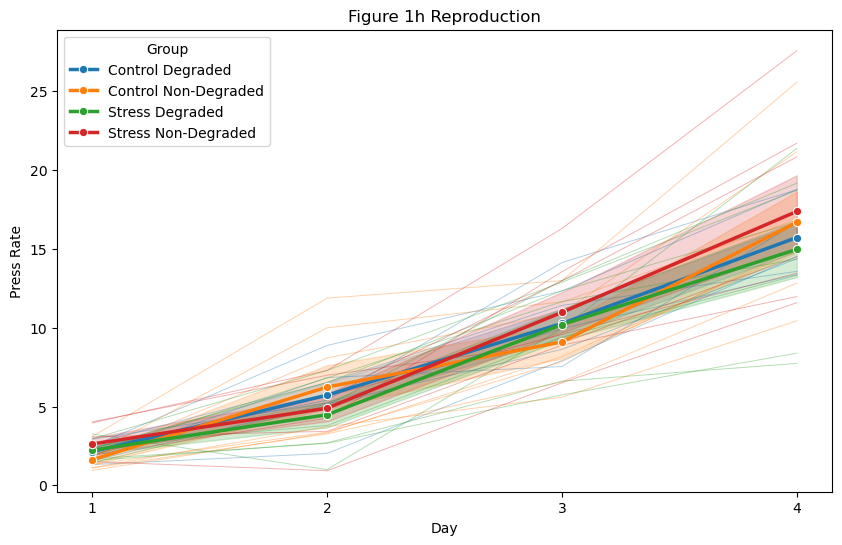

In [112]:
plt.figure(figsize=(10,6))

# Individual mouse lines

ind_mouse_line = sns.lineplot( 
    data=df_1h,
    x='Day',
    y='PressRate',
    hue='Group',
    estimator=None,
    units='Subject_ID',
    lw=0.7,
    alpha=0.35,
    legend=False     
)

# Main lines
main_group = sns.lineplot(
    data=df_1h,
    x='Day',
    y='PressRate',
    hue='Group',
    errorbar='se',
    lw=2.5,
    marker='o'
)

# Fix legend
handles, labels = meanplot.get_legend_handles_labels() # show all groups in legend
plt.legend(handles, labels, title='Group')

plt.title('Figure 1h Reproduction')
plt.xlabel('Day')
plt.xticks([1, 2, 3, 4])
plt.ylabel('Press Rate')
plt.show()



In [113]:
# Need to do RM ANOVA here

In [114]:
# Figure 1i DATA LOADING

data_1i = pd.read_csv('1i.csv')

data_1i = data_1i.rename(columns={'Subject ID': 'Subject_ID', 'Press Rate': 'Press_Rate'}) # Rename columns

data_1i['Group'] = data_1i['Group'].astype('category')

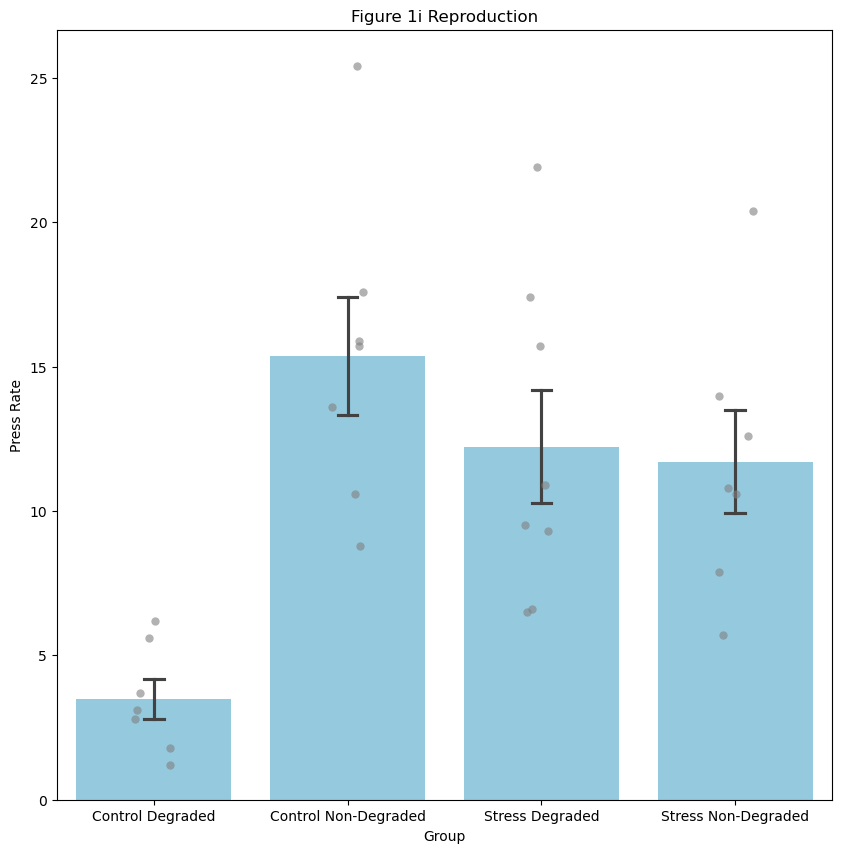

In [115]:
# Plot for Figure 1i

plt.figure(figsize=(10,10)) #make figure bigger

# Bar plot: mean ± SE
sns.barplot(
    data=data_1i,
    x='Group',
    y='Press_Rate',
    errorbar=('se'),          # standard error
    capsize=0.1,
    color='skyblue'
)

# Individual values
sns.stripplot(
    data=data_1i,
    x='Group',
    y='Press_Rate',
    jitter=True,
    color='gray',     # lighter color for individual points
    alpha=0.6,
    size=6
)

plt.title('Figure 1i Reproduction')
plt.xlabel('Group')
plt.ylabel('Press Rate')
plt.show()

In [108]:
# Need to do ANOVA here